<a href="https://colab.research.google.com/github/Musarrat1/tea-house/blob/main/tealeaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, glob, numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!rm -rf /content/dataset
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/TeaDataset.zip" -d /content/dataset

!ls /content/dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TeaDataset


In [3]:
candidates = [
    "/content/dataset/TeaDataset",
    "/content/dataset",
    "/content/TeaDataset"
]

DATA_DIR = None
for p in candidates:
    if os.path.isdir(p):
        subdirs = [d for d in os.listdir(p) if os.path.isdir(os.path.join(p, d))]
        # we expect class folders here
        if len(subdirs) >= 2:
            DATA_DIR = p
            break

print("✅ DATA_DIR =", DATA_DIR)
print("✅ Class folders:", [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])





✅ DATA_DIR = /content/dataset/TeaDataset
✅ Class folders: ['Grey Blight', '7. Healthy leaf', 'Helopelties', 'Brown Blight', 'Red rust']


In [4]:
for c in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, c)
    if os.path.isdir(p):
        n = len(glob.glob(os.path.join(p, "*.*")))
        print(f"{c}: {n}")


7. Healthy leaf: 935
Brown Blight: 984
Grey Blight: 1019
Helopelties: 789
Red rust: 465


In [5]:
IMG_SIZE = (256, 256)
BATCH = 32
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("✅ Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 4192 files belonging to 5 classes.
Using 3354 files for training.
Found 4192 files belonging to 5 classes.
Using 838 files for validation.
✅ Classes: ['7. Healthy leaf', 'Brown Blight', 'Grey Blight', 'Helopelties', 'Red rust']


In [6]:
from sklearn.utils.class_weight import compute_class_weight

y_train = []
for _, y in train_ds.unbatch():
    y_train.append(np.argmax(y.numpy()))
y_train = np.array(y_train)

weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

# clip aggressive weights
class_weights_clipped = {k: float(min(v, 2.0)) for k, v in class_weights.items()}

print("Raw weights:", class_weights)
print("✅ Clipped weights:", class_weights_clipped)

Raw weights: {0: np.float64(0.9028263795423956), 1: np.float64(0.8406015037593985), 2: np.float64(0.819047619047619), 3: np.float64(1.0819354838709678), 4: np.float64(1.7935828877005349)}
✅ Clipped weights: {0: 0.9028263795423956, 1: 0.8406015037593985, 2: 0.819047619047619, 3: 1.0819354838709678, 4: 1.7935828877005349}


In [7]:
aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [9]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_clipped,
    callbacks=callbacks
)

print("Head train acc:", history.history["accuracy"][-1])
print("Head val acc  :", history.history["val_accuracy"][-1])

if "history_ft" in globals():
    print("FT train acc :", history_ft.history["accuracy"][-1])
    print("FT val acc   :", history_ft.history["val_accuracy"][-1])

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 443s 4s/step - accuracy: 0.4910 - loss: 1.2478 - val_accuracy: 0.7351 - val_loss: 0.7370 - learning_rate: 0.0010
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 399s 4s/step - accuracy: 0.7446 - loss: 0.6944 - val_accuracy: 0.7936 - val_loss: 0.5681 - learning_rate: 0.0010
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.7771 - loss: 0.5980 - val_accuracy: 0.8234 - val_loss: 0.4977 - learning_rate: 0.0010
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 401s 4s/step - accuracy: 0.8141 - loss: 0.5185 - val_accuracy: 0.8186 - val_loss: 0.4931 - learning_rate: 0.0010
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.8125 - loss: 0.5047 - val_accuracy: 0.8162 - val_loss: 0.4859 - learning_rate: 0.0010
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 431s 4s/step - accuracy: 0.8282 - loss: 0.4685 - val_accuracy: 0.8473 - val_loss: 0.4121 - learning_rate: 0.0010
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 438s 4s/step - accuracy: 0.8385 - loss: 0.

Epoch 1/8
105/105 ━━━━━━━━━━━━━━━━━━━━ 454s 4s/step - accuracy: 0.8356 - loss: 0.4642 - val_accuracy: 0.8556 - val_loss: 0.3642 - learning_rate: 1.0000e-05
Epoch 2/8
105/105 ━━━━━━━━━━━━━━━━━━━━ 435s 4s/step - accuracy: 0.8367 - loss: 0.4346 - val_accuracy: 0.8556 - val_loss: 0.3546 - learning_rate: 1.0000e-05
Epoch 3/8
105/105 ━━━━━━━━━━━━━━━━━━━━ 447s 4s/step - accuracy: 0.8602 - loss: 0.4101 - val_accuracy: 0.8616 - val_loss: 0.3533 - learning_rate: 1.0000e-05
Epoch 4/8
105/105 ━━━━━━━━━━━━━━━━━━━━ 443s 4s/step - accuracy: 0.8497 - loss: 0.4089 - val_accuracy: 0.8699 - val_loss: 0.3368 - learning_rate: 1.0000e-05
Epoch 5/8
105/105 ━━━━━━━━━━━━━━━━━━━━ 437s 4s/step - accuracy: 0.8624 - loss: 0.3753 - val_accuracy: 0.8759 - val_loss: 0.3319 - learning_rate: 1.0000e-05
Epoch 6/8
105/105 ━━━━━━━━━━━━━━━━━━━━ 439s 4s/step - accuracy: 0.8634 - loss: 0.3725 - val_accuracy: 0.8771 - val_loss: 0.3241 - learning_rate: 1.0000e-05
Epoch 7/8
105/105 ━━━━━━━━━━━━━━━━━━━━ 433s 4s/step - accuracy: 

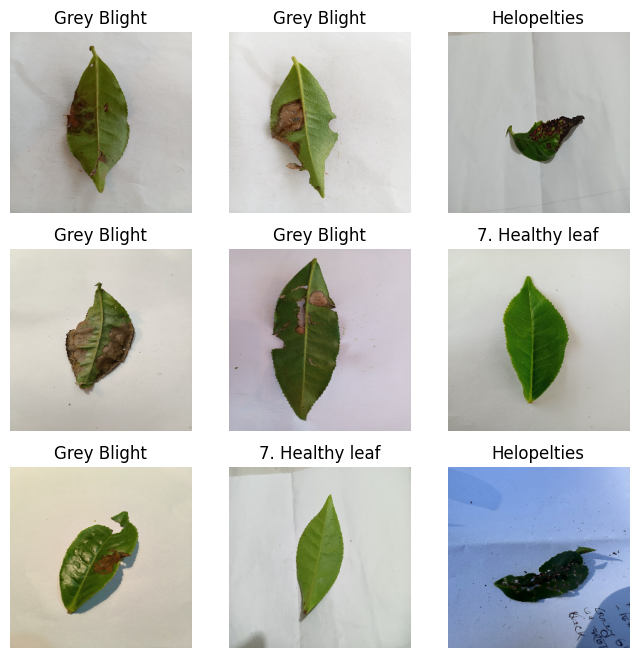

In [16]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weights_clipped,
    callbacks=callbacks
)


for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[tf.argmax(labels[i])])
        plt.axis("off")

✅ Pred distribution: {'Brown Blight': 167, 'Red rust': 113, '7. Healthy leaf': 191, 'Grey Blight': 217, 'Helopelties': 150}
✅ True distribution: {'Brown Blight': 186, 'Red rust': 91, '7. Healthy leaf': 192, 'Helopelties': 169, 'Grey Blight': 200}

✅ Classification Report:

                 precision    recall  f1-score   support

7. Healthy leaf     0.9634    0.9583    0.9608       192
   Brown Blight     0.9042    0.8118    0.8555       186
    Grey Blight     0.8157    0.8850    0.8489       200
    Helopelties     0.9800    0.8698    0.9216       169
       Red rust     0.6991    0.8681    0.7745        91

       accuracy                         0.8807       838
      macro avg     0.8725    0.8786    0.8723       838
   weighted avg     0.8896    0.8807    0.8826       838



<Figure size 800x800 with 0 Axes>

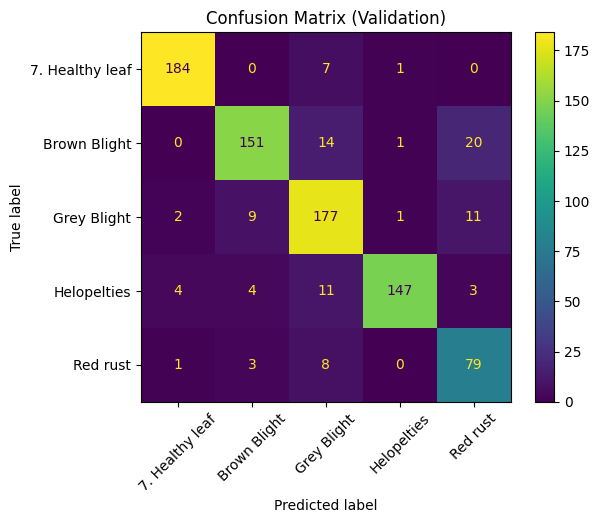

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("✅ Pred distribution:", {class_names[k]: v for k, v in Counter(y_pred).items()})
print("✅ True distribution:", {class_names[k]: v for k, v in Counter(y_true).items()})
print("\n✅ Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

plt.figure(figsize=(8,8))
disp.plot(values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix (Validation)")
plt.show()

In [ ]:
remedy = {
    "Healthy": "Healthy leaf: monitor regularly and maintain field hygiene.",
    "BrownBlight": "Brown blight: remove infected leaves, improve airflow, fungicide if severe.",
    "GreyBlight": "Grey blight: prune infected parts, reduce humidity, fungicide if severe.",
    "RedRust": "Red rust: improve sunlight exposure, copper spray if needed.",
    "Helopeltis": "Helopeltis: IPM—monitoring, pruning, neem-based spray / control if infestation rises."
}

In [14]:
images, labels = next(iter(val_ds))
img = images[0]
true_label = int(np.argmax(labels[0].numpy()))

pred = model.predict(np.expand_dims(img.numpy(), axis=0), verbose=0)
pred_label = int(np.argmax(pred[0]))

pred_class = class_names[pred_label]
print("True:", class_names[true_label])
print("Predicted:", pred_class)
print("Remedy:", remedy.get(pred_class, "Consult an agriculture expert."))

True: Brown Blight
Predicted: Brown Blight
Remedy: Consult an agriculture expert.


In [15]:
# save model
model.save("tea_leaf_model_final.keras")
!cp tea_leaf_model_final.keras /content/drive/MyDrive/

# save report text
from sklearn.metrics import classification_report
report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4)

with open("classification_report.txt", "w") as f:
    f.write("Classes: " + str(class_names) + "\n\n")
    f.write(report_text)

!cp classification_report.txt /content/drive/MyDrive/
print("✅ Saved model + report to MyDrive")


✅ Saved model + report to MyDrive


# Task
Update the tea leaf disease classification model by:
1.  Changing the image size to `(300, 300)`.
2.  Applying stronger data augmentation with `RandomFlip("horizontal")`, `RandomRotation(0.2)`, `RandomZoom(0.2)`, `RandomContrast(0.2)`, and `RandomBrightness(0.2)`.
3.  Increasing the model's dropout rate to `0.45` and using `CategoricalCrossentropy` with `label_smoothing=0.1` for the loss function.
4.  Retraining the model's head.
5.  Fine-tuning the last 40 layers of the `base_model`.
6.  Evaluating the final model's performance using a classification report and confusion matrix, testing a sample prediction, and saving the updated model and report to Google Drive.
Finally, summarize the performed changes, the evaluation results, and discuss potential next steps for further improvement.

## Update Image Size and Recreate Datasets

### Subtask:
Modify the `IMG_SIZE` variable to `(300, 300)` and re-run the cell to recreate the `train_ds` and `val_ds` with the new image dimensions.


**Reasoning**:
The user wants to modify the `IMG_SIZE` variable and recreate the datasets. I will modify the content of cell `67362648` to change `IMG_SIZE` to `(300, 300)` and then run the cell to update `train_ds` and `val_ds`.



**Reasoning**:
The user wants to apply stronger data augmentation. I will modify the existing data augmentation layer to include `RandomFlip("horizontal")`, `RandomRotation(0.2)`, `RandomZoom(0.2)`, `RandomContrast(0.2)`, and `RandomBrightness(0.2)`.



**Reasoning**:
The next step is to update the model's dropout rate and use `CategoricalCrossentropy` with `label_smoothing=0.1` as the loss function. I will modify the existing model definition to reflect these changes.



**Reasoning**:
I need to compile the model with the `CategoricalCrossentropy` loss function, applying `label_smoothing=0.1` as requested. Then, I will fit the model using the `train_ds` and `val_ds` to retrain the model's head.



# Task
Update the tea leaf disease classification model by:
1. Changing the image size to `(300, 300)`.
2. Applying stronger data augmentation with `RandomFlip("horizontal")`, `RandomRotation(0.2)`, `RandomZoom(0.2)`, `RandomContrast(0.2)`, and `RandomBrightness(0.2)`.
3. Increasing the model's dropout rate to `0.45` and using `CategoricalCrossentropy` with `label_smoothing=0.1` for the loss function.
4. Retraining the model's head.
5. Fine-tuning the last 40 layers of the `base_model`.
6. Evaluating the final model's performance using a classification report and confusion matrix, testing a sample prediction, and saving the updated model and report to Google Drive.
Finally, summarize the performed changes, the evaluation results, and discuss potential next steps for further improvement.

## Update Data Augmentation Layers

### Subtask:
Replace the existing data augmentation layers with stronger augmentation: `layers.RandomFlip("horizontal")`, `layers.RandomRotation(0.2)`, `layers.RandomZoom(0.2)`, `layers.RandomContrast(0.2)`, and `layers.RandomBrightness(0.2)`.


The `data_augmentation` sequential model in cell `690ecc8c` has already been updated with `layers.RandomFlip("horizontal")`, `layers.RandomRotation(0.2)`, `layers.RandomZoom(0.2)`, `layers.RandomContrast(0.2)`, and `layers.RandomBrightness(0.2)`.

## Rebuild Model with Increased Dropout

### Subtask:
Rebuild the model with the increased dropout rate (0.45) and updated data augmentation layers.


**Reasoning**:
I need to execute cell `1f154314` to rebuild the model with the updated dropout rate and data augmentation layers, as instructed.



**Reasoning**:
The next step is to retrain the model's head. I will compile the model with `CategoricalCrossentropy` loss using `label_smoothing=0.1` and then fit it to the training data.



**Reasoning**:
The user wants to compile the model with CategoricalCrossentropy loss (label_smoothing=0.1) and retrain its head. I will use the existing `callbacks` and `class_weights_clipped` from the previous steps to ensure proper training.

